# Chapter 6: building your first deep neural network: introduction to backpropagation

Haikal Ali TK-46-GAB 1103223071

## In this chapter

- The streetlight problem
- Matrices and the matrix relationship
- Full, batch, and stochastic gradient descent
- Neural networks learn correlation
- Overfitting
- Creating your own correlation
- Backpropagation: long-distance error attribution
- Linear versus nonlinear
- The secret to sometimes correlation
- Your first deep network
- Backpropagation in code: bringing it all together

## The streetlight problem

Masalah streetlight adalah toy problem untuk melihat bagaimana network belajar dari keseluruhan dataset.

Bayangkan kamu berada di negara asing dan melihat lampu penyeberangan yang tidak familiar. Untuk mengetahui kapan aman menyeberang, kamu bisa mengamati hubungan antara kombinasi lampu dan keputusan orang di sekitar: apakah mereka berjalan atau berhenti.

Dari beberapa pengamatan, pola mulai terlihat. Pada data ini, lampu tengah memiliki korelasi sempurna dengan apakah orang berjalan atau berhenti. Pola itulah yang akan dilatih agar dapat dipelajari oleh neural network.

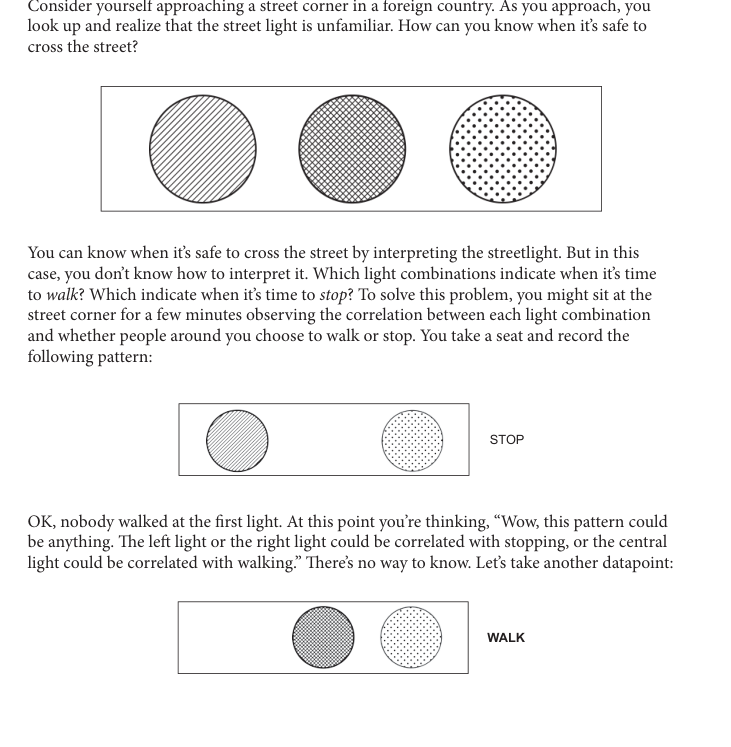

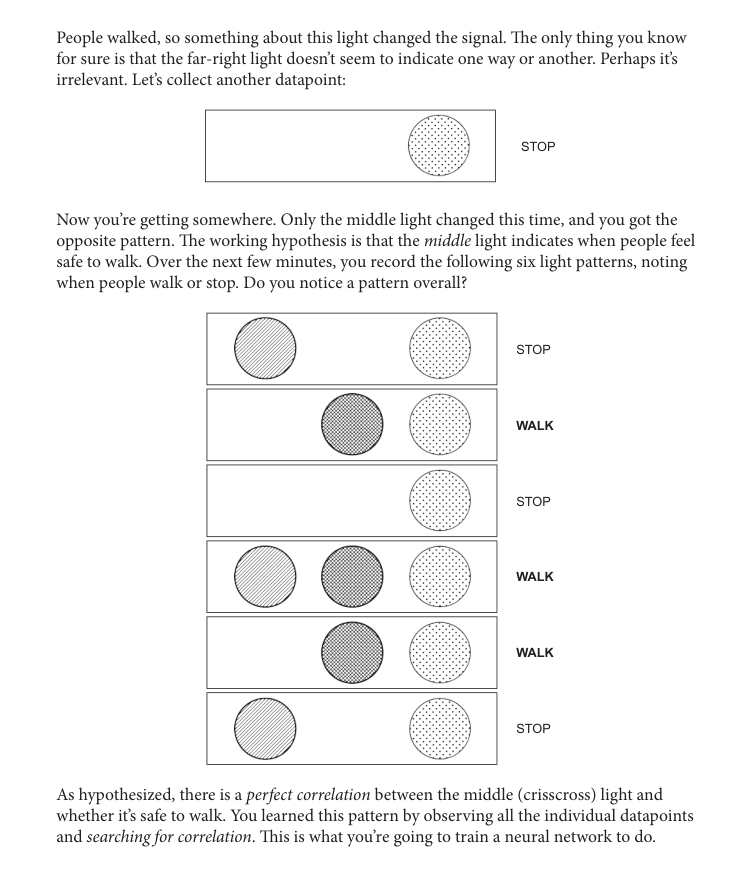

## Preparing the data

Neural network tidak membaca streetlight secara langsung.

Supervised algorithms menerima satu dataset dan mengubahnya menjadi dataset lain. Dalam kasus streetlight, ada dua dataset:

- Dataset yang diketahui: enam kondisi streetlight.
- Dataset yang ingin diketahui: enam observasi apakah orang berjalan atau berhenti.

Tujuan neural network adalah mempelajari cara mengubah dataset streetlight menjadi dataset walk/stop.

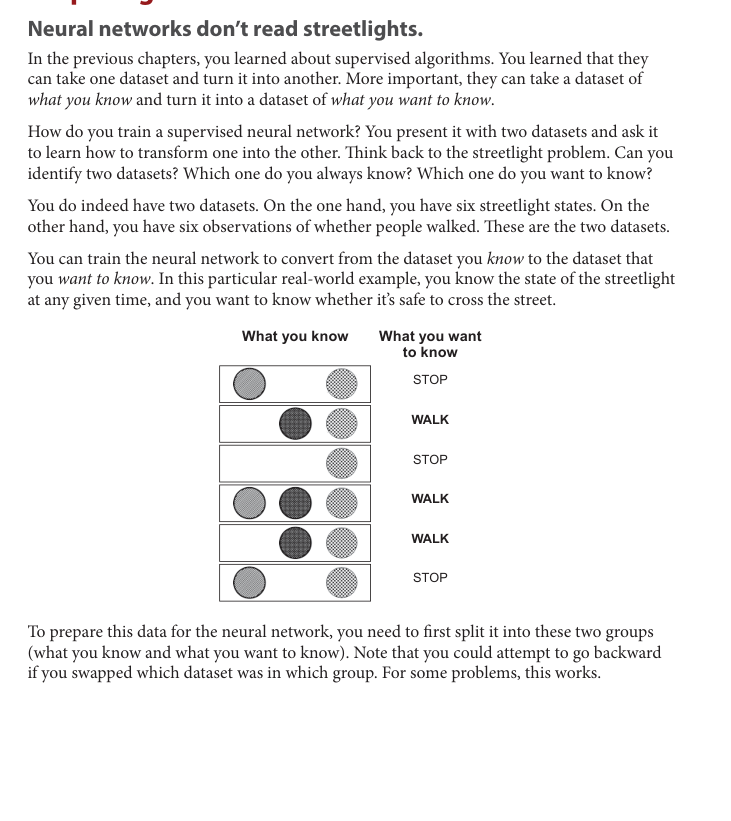

## Matrices and the matrix relationship

Streetlight perlu diterjemahkan ke bentuk matematika.

Pola streetlight dapat direpresentasikan dengan angka 1 dan 0. Setiap lampu menjadi satu kolom, dan setiap pengamatan menjadi satu baris. Struktur seperti ini disebut matrix.

Dalam data matrix, setiap recorded example biasanya menjadi satu row, sedangkan setiap hal yang direkam menjadi satu column. Jadi, satu column berisi semua keadaan satu lampu, dan satu row berisi keadaan semua lampu pada satu waktu tertentu.

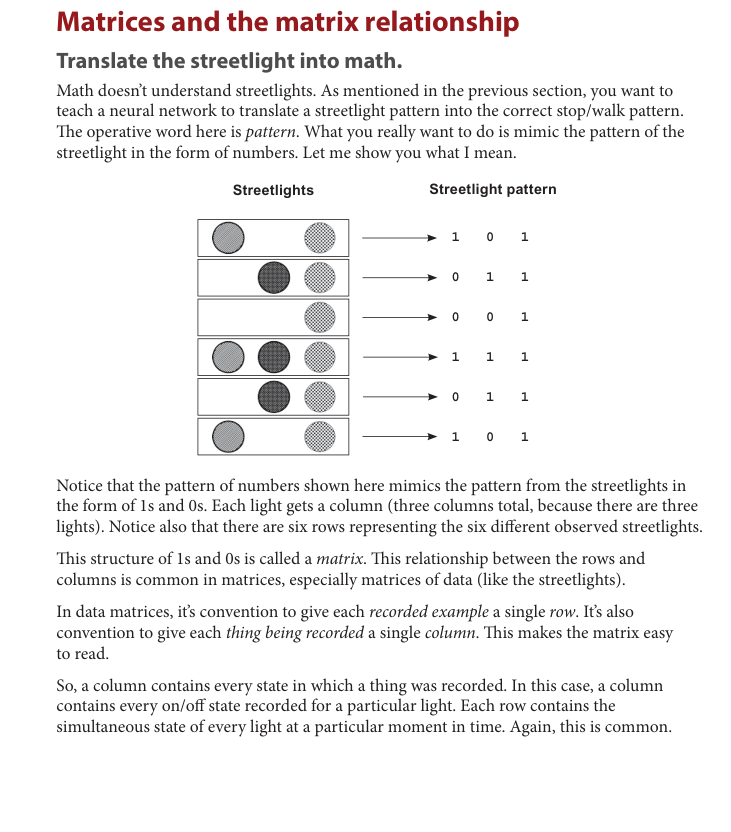

Data matrix yang baik meniru pola dunia nyata.

Matrix tidak harus hanya berisi 1 dan 0. Jika lampu memiliki tingkat intensitas berbeda, matrix bisa berisi nilai seperti 0.9, 0.8, atau 0.1. Matrix lain yang merupakan scalar multiple dari matrix tersebut tetap dapat menangkap pola dasar yang sama.

Hal pentingnya adalah pattern bukan matrix itu sendiri, melainkan properti yang diekspresikan oleh matrix.

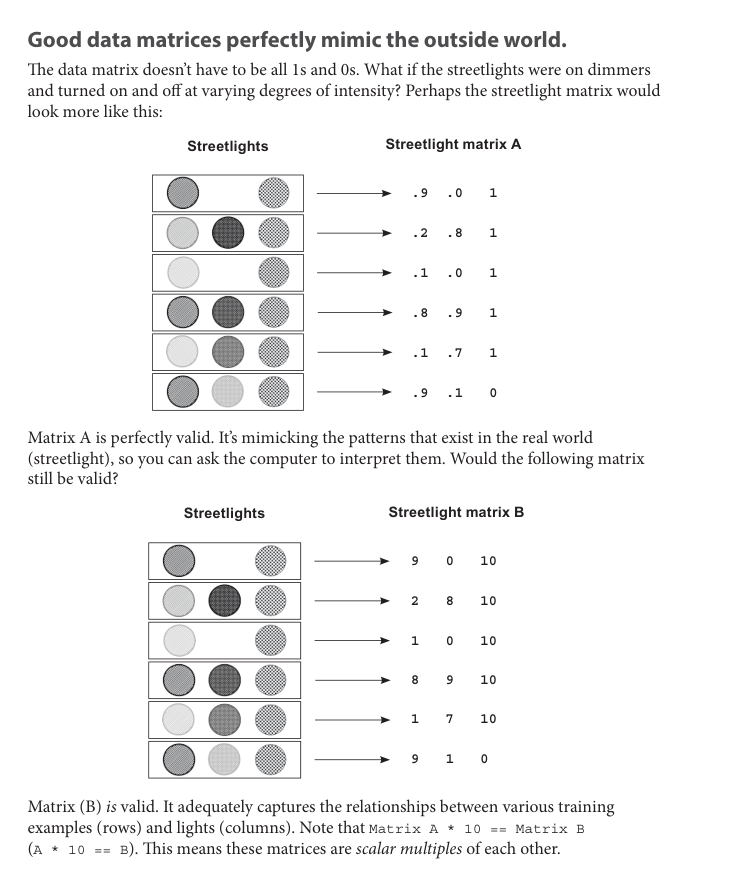

Output data juga perlu direpresentasikan sebagai matrix. Label STOP/WALK dapat dibuat menjadi 0 dan 1. Selama representasi itu dapat dikonversi kembali secara sempurna ke catatan stop/walk, representasi tersebut bersifat lossless.

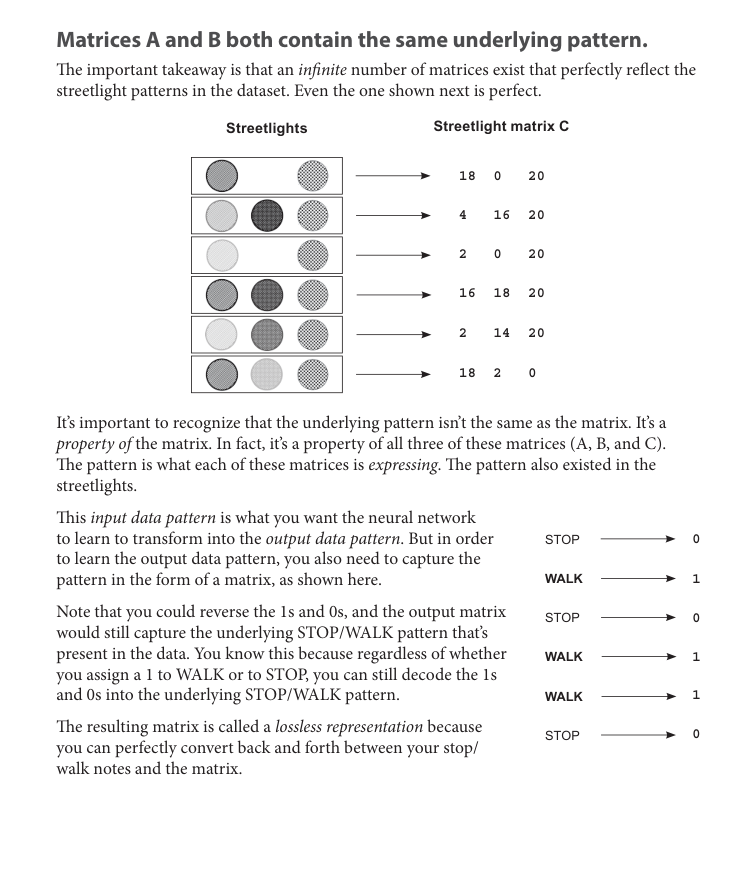

## Creating a matrix or two in Python

Matrix streetlight dan output dapat dibuat di Python menggunakan NumPy.

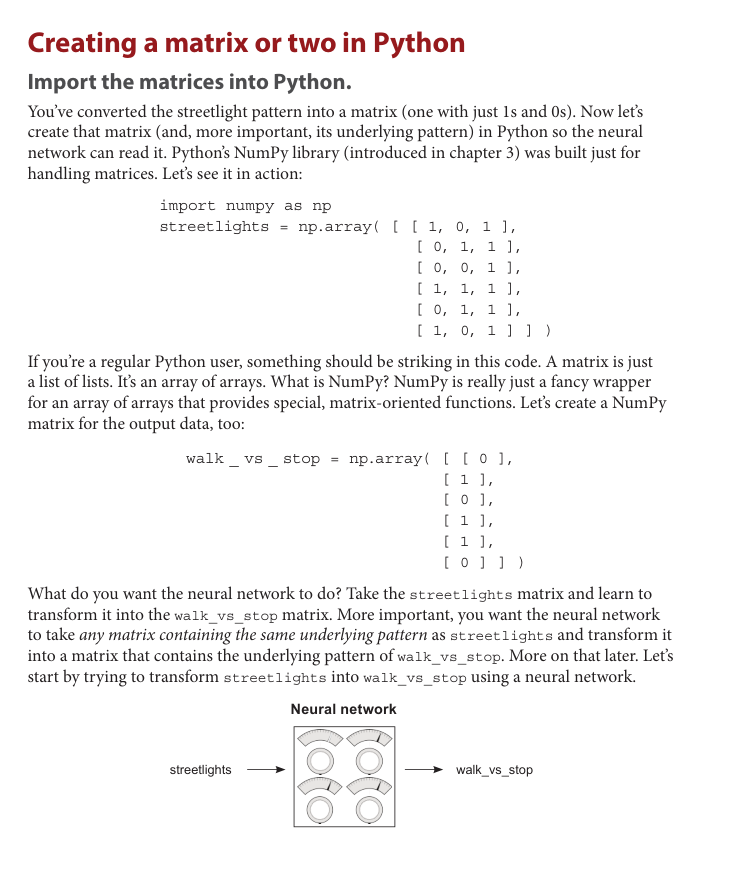

In [1]:
import numpy as np

streetlights = np.array([
  [1, 0, 1],
  [0, 1, 1],
  [0, 0, 1],
  [1, 1, 1],
  [0, 1, 1],
  [1, 0, 1]
])

walk_vs_stop = np.array([
  [0],
  [1],
  [0],
  [1],
  [1],
  [0]
])

print(streetlights)
print(walk_vs_stop)

[[1 0 1]
 [0 1 1]
 [0 0 1]
 [1 1 1]
 [0 1 1]
 [1 0 1]]
[[0]
 [1]
 [0]
 [1]
 [1]
 [0]]


Matrix pada NumPy pada dasarnya adalah list of lists. NumPy menyediakan fungsi khusus untuk operasi yang berorientasi matrix.

Target neural network adalah mengambil matrix `streetlights` dan mempelajari cara mengubahnya menjadi matrix `walk_vs_stop`.

## Building a neural network

Kode berikut mencoba mempelajari pattern streetlight pertama.

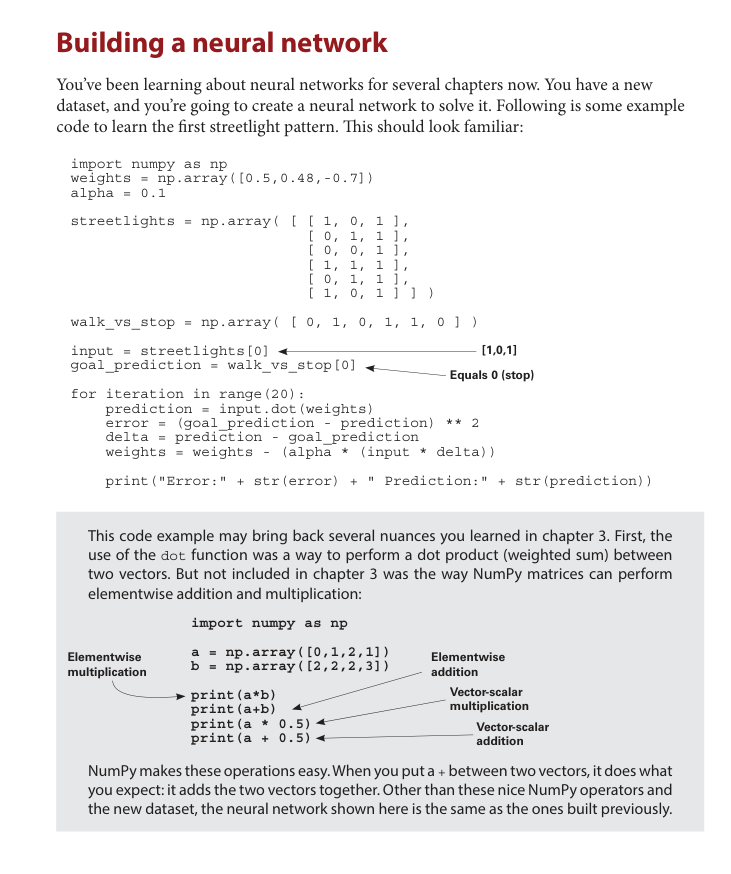

In [2]:
import numpy as np

weights = np.array([0.5, 0.48, -0.7])
alpha = 0.1

streetlights = np.array([
  [1, 0, 1],
  [0, 1, 1],
  [0, 0, 1],
  [1, 1, 1],
  [0, 1, 1],
  [1, 0, 1]
])

walk_vs_stop = np.array([0, 1, 0, 1, 1, 0])

input = streetlights[0]
goal_prediction = walk_vs_stop[0]

for iteration in range(20):
  prediction = input.dot(weights)
  error = (goal_prediction - prediction) ** 2
  delta = prediction - goal_prediction
  weights = weights - (alpha * (input * delta))

  print("Error:" + str(error) + " Prediction:" + str(prediction))

Error:0.03999999999999998 Prediction:-0.19999999999999996
Error:0.025599999999999973 Prediction:-0.15999999999999992
Error:0.01638399999999997 Prediction:-0.1279999999999999
Error:0.010485759999999964 Prediction:-0.10239999999999982
Error:0.006710886399999962 Prediction:-0.08191999999999977
Error:0.004294967295999976 Prediction:-0.06553599999999982
Error:0.002748779069439994 Prediction:-0.05242879999999994
Error:0.0017592186044416036 Prediction:-0.04194304000000004
Error:0.0011258999068426293 Prediction:-0.03355443200000008
Error:0.0007205759403792803 Prediction:-0.02684354560000002
Error:0.0004611686018427356 Prediction:-0.021474836479999926
Error:0.0002951479051793508 Prediction:-0.01717986918399994
Error:0.00018889465931478573 Prediction:-0.013743895347199997
Error:0.00012089258196146188 Prediction:-0.010995116277759953
Error:7.737125245533561e-05 Prediction:-0.008796093022207963
Error:4.951760157141604e-05 Prediction:-0.007036874417766459
Error:3.169126500570676e-05 Prediction:-0.0

Pada kode tersebut, `dot` digunakan untuk melakukan dot product atau weighted sum antara dua vector. NumPy juga dapat melakukan elementwise addition dan elementwise multiplication.

In [3]:
import numpy as np

a = np.array([0, 1, 2, 1])
b = np.array([2, 2, 2, 3])

print(a * b)
print(a + b)
print(a * 0.5)
print(a + 0.5)

[0 2 4 3]
[2 3 4 4]
[0.  0.5 1.  0.5]
[0.5 1.5 2.5 1.5]


## Learning the whole dataset

Sampai titik ini, network hanya belajar dari satu streetlight. Agar network dapat mempelajari semua data, training dilakukan pada semua streetlights.

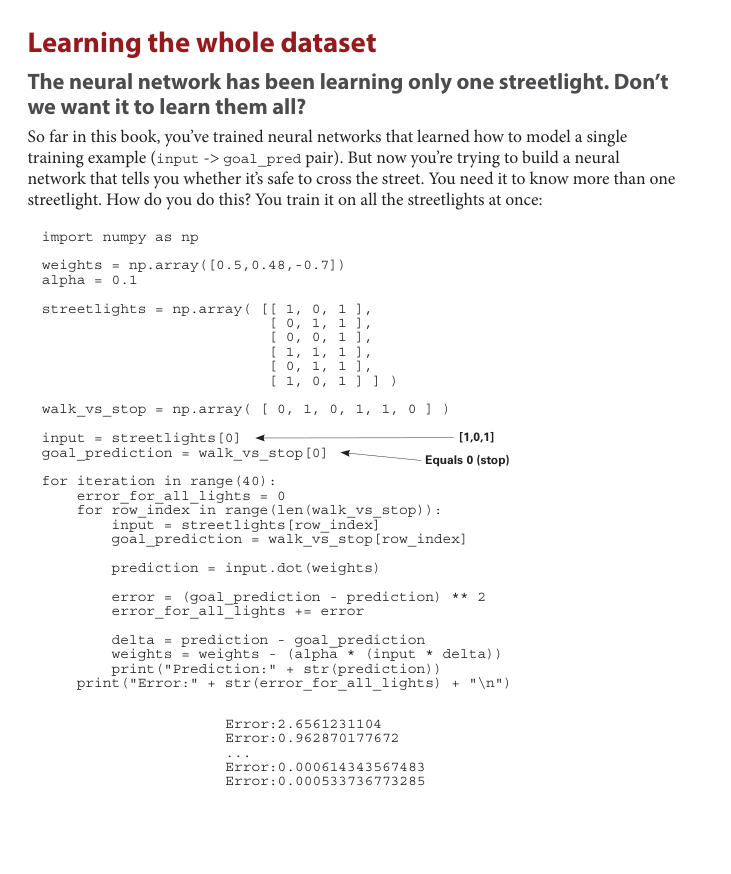

In [4]:
import numpy as np

weights = np.array([0.5, 0.48, -0.7])
alpha = 0.1

streetlights = np.array([
  [1, 0, 1],
  [0, 1, 1],
  [0, 0, 1],
  [1, 1, 1],
  [0, 1, 1],
  [1, 0, 1]
])

walk_vs_stop = np.array([0, 1, 0, 1, 1, 0])

for iteration in range(40):
  error_for_all_lights = 0

  for row_index in range(len(walk_vs_stop)):
    input = streetlights[row_index]
    goal_prediction = walk_vs_stop[row_index]

    prediction = input.dot(weights)
    error = (goal_prediction - prediction) ** 2
    error_for_all_lights += error

    delta = prediction - goal_prediction
    weights = weights - (alpha * (input * delta))

  if iteration < 5 or iteration > 34:
    print("Error:" + str(error_for_all_lights))

  if iteration == 5:
    print("...")

Error:2.6561231104
Error:0.9628701776715985
Error:0.5509165866836797
Error:0.36445836852222424
Error:0.2516768662079895
...
Error:0.0009368896209360312
Error:0.0008139366504753339
Error:0.0007071291752624441
Error:0.0006143435674831474
Error:0.00053373677328488


## Full, batch, and stochastic gradient descent

Metode yang mempelajari satu example pada satu waktu disebut **stochastic gradient descent**. Pada metode ini, network membuat prediction dan update weight untuk setiap training example secara terpisah.

**Full gradient descent** atau average gradient descent memperbarui weights satu dataset pada satu waktu. Network menghitung rata-rata `weight_delta` dari seluruh dataset, lalu weights diubah setelah rata-rata penuh dihitung.

**Batch gradient descent** berada di antara keduanya. Weights diperbarui setelah sejumlah contoh tertentu. Batch size umumnya berada di antara 8 sampai 256.

Contoh streetlight sebelumnya memakai stochastic gradient descent karena network memperbarui weights setelah setiap example.

## Neural networks learn correlation

Network single-layer yang dilatih pada streetlight belajar mengidentifikasi input mana yang berkorelasi dengan output.

Pada hasil training, weight tengah mendekati 1, sedangkan weight kiri dan kanan mendekati 0. Artinya, network menemukan bahwa input tengah memiliki korelasi kuat dengan output walk/stop, sementara input lain cenderung tidak relevan terhadap output.

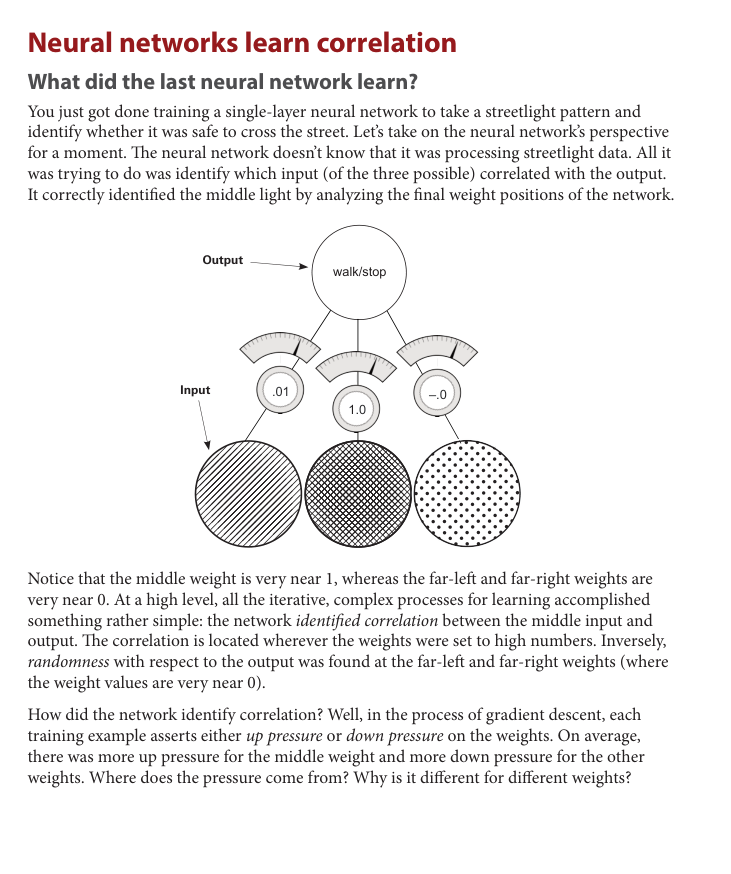

Gradient descent menghasilkan tekanan naik atau turun pada weights. Secara rata-rata, middle weight menerima lebih banyak upward pressure, sedangkan weights lain menerima lebih banyak downward pressure.

## Up and down pressure

Tekanan naik dan turun berasal dari data.

Setiap node mencoba memprediksi output berdasarkan input. Error dibagi bersama oleh semua weights. Untuk melakukan error attribution, network perlu mengetahui weights mana yang berkontribusi terhadap error dan weights mana yang tidak.

Jika input suatu weight bernilai 0, weight tersebut tidak berkontribusi pada prediction, karena nilai apa pun akan dikalikan 0. Karena itu, weight tersebut tidak mendapat pressure.

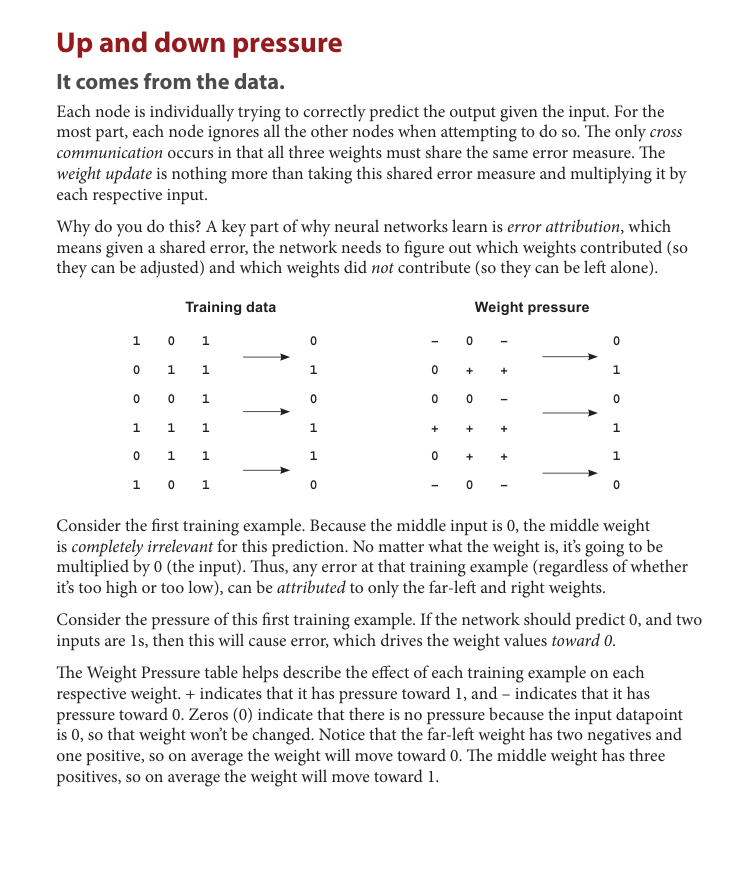

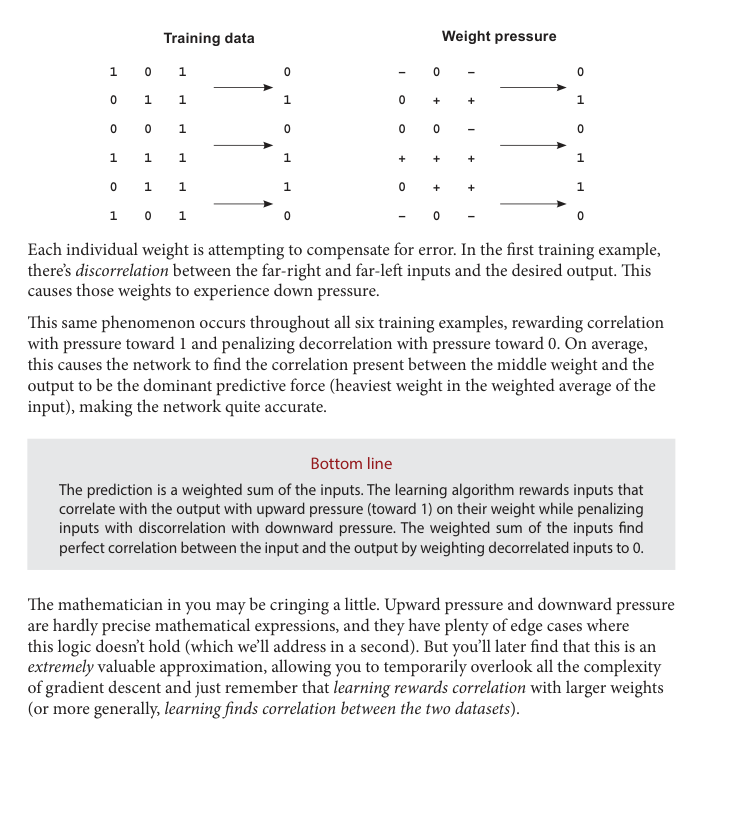

Learning algorithm memberi reward pada input yang berkorelasi dengan output melalui pressure menuju 1. Input yang tidak berkorelasi atau decorrelated diberi pressure menuju 0. Weighted sum dapat menemukan correlation antara input dan output dengan memberi bobot 0 pada input yang decorrelated.

## Edge case: Overfitting

Kadang correlation terjadi secara tidak sengaja.

Jika konfigurasi weights tertentu secara tidak sengaja menghasilkan prediction sempurna pada sebagian training data, network dapat berhenti belajar meskipun belum benar-benar mempelajari pola yang general.

Fenomena ini disebut overfitting. Masalah utamanya adalah network dapat menghafal sebagian training examples, bukan menemukan correlation yang dapat digunakan untuk data lain.

Deep learning memiliki tantangan besar: membuat neural network generalize, bukan sekadar memorize.

## Edge case: Conflicting pressure

Kadang correlation saling bertarung.

Pada kolom far-right, terlihat jumlah upward dan downward pressure dapat tampak seimbang. Namun network tetap dapat mendorong weight tersebut menuju 0 karena pressure turun lebih besar setelah weight lain mulai menyerap correlation yang lebih kuat.

Ketika weight kiri dan tengah mulai mendekati posisi optimal, decorrelation pada weight kanan menjadi lebih jelas.

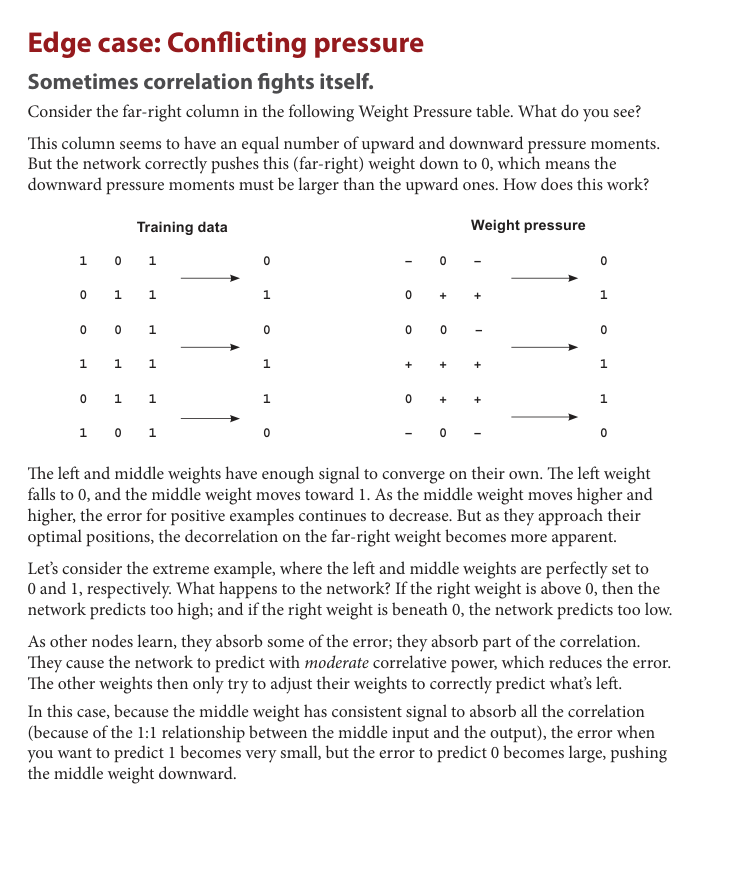

Tidak selalu prosesnya berjalan semudah itu. Jika middle node tidak berkorelasi sempurna, network bisa kesulitan menghilangkan pengaruh far-right weight.

Regularization disebut sebagai teknik yang nantinya akan membantu memaksa weights dengan conflicting pressure bergerak menuju 0. Idenya, hanya weights dengan correlation kuat yang dipertahankan, sedangkan sisanya dimatikan karena dianggap menambah noise.

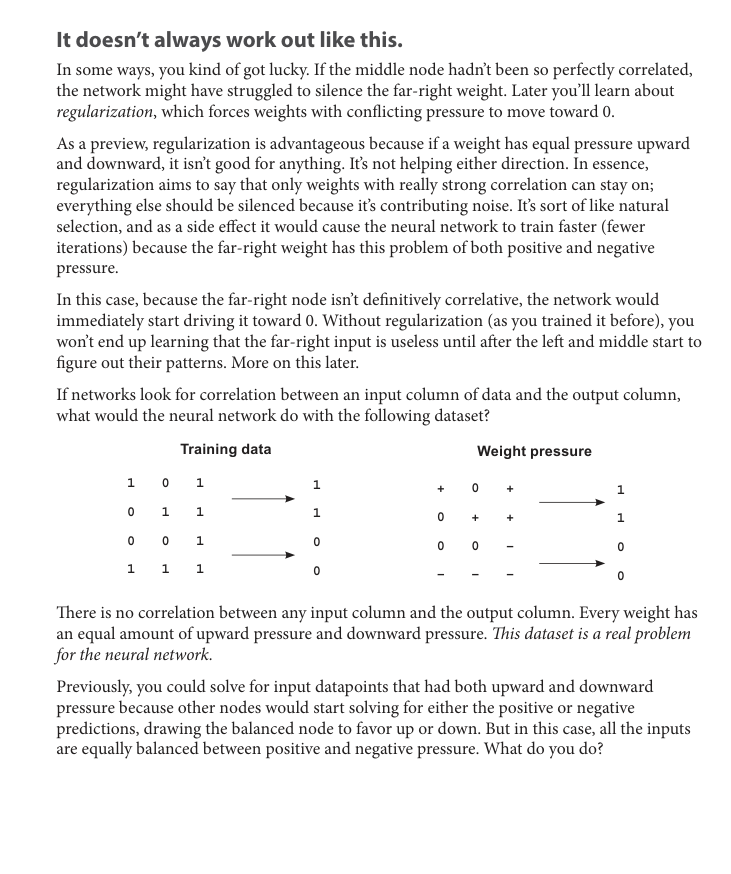

Jika dataset tidak memiliki correlation antara input columns dan output column, semua weights dapat menerima upward dan downward pressure yang seimbang. Dataset seperti ini menjadi masalah bagi neural network single-layer.

## Learning indirect correlation

Jika data tidak memiliki correlation langsung, intermediate data dapat dibuat agar memiliki correlation.

Neural network sebenarnya mencari correlation antara input layer dan output layer. Jika input dataset tidak berkorelasi dengan output dataset, solusinya adalah menggunakan dua network yang ditumpuk. Network pertama membuat intermediate dataset, lalu network kedua memakai intermediate dataset tersebut untuk memprediksi output.

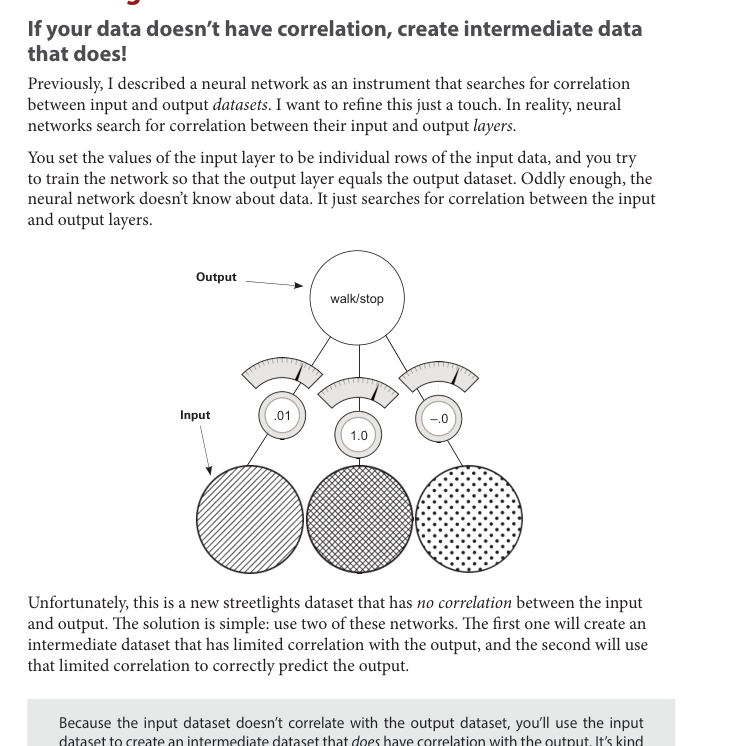

## Creating correlation

Network baru dibuat dengan menumpuk dua neural networks. Middle layer atau `layer_1` menjadi intermediate dataset.

Tujuannya adalah membuat `layer_1` yang berasal dari `layer_0` memiliki correlation dengan `layer_2`, meskipun `layer_0` dan `layer_2` tidak memiliki correlation langsung.

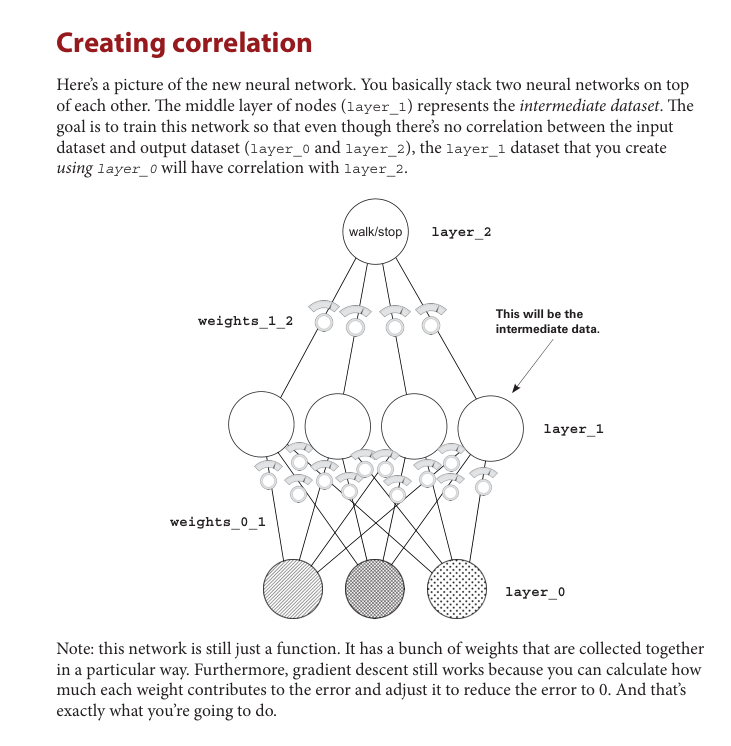

Network ini tetap merupakan function dengan kumpulan weights yang disusun dengan cara tertentu. Gradient descent tetap dapat digunakan karena kontribusi setiap weight terhadap error dapat dihitung dan disesuaikan untuk menurunkan error.

## Stacking neural networks: A review

Pada stacked neural networks, output dari network pertama menjadi input untuk network kedua. Output dari `layer_0` ke `layer_1` menjadi input untuk network dari `layer_1` ke `layer_2`.

Bagian atas network, yaitu `layer_1` ke `layer_2`, dapat dipelajari dengan logic yang sama seperti chapter sebelumnya. Bagian yang belum jelas adalah cara memperbarui weights dari `layer_0` ke `layer_1`. Untuk itu, perlu diketahui nilai delta pada `layer_1`.

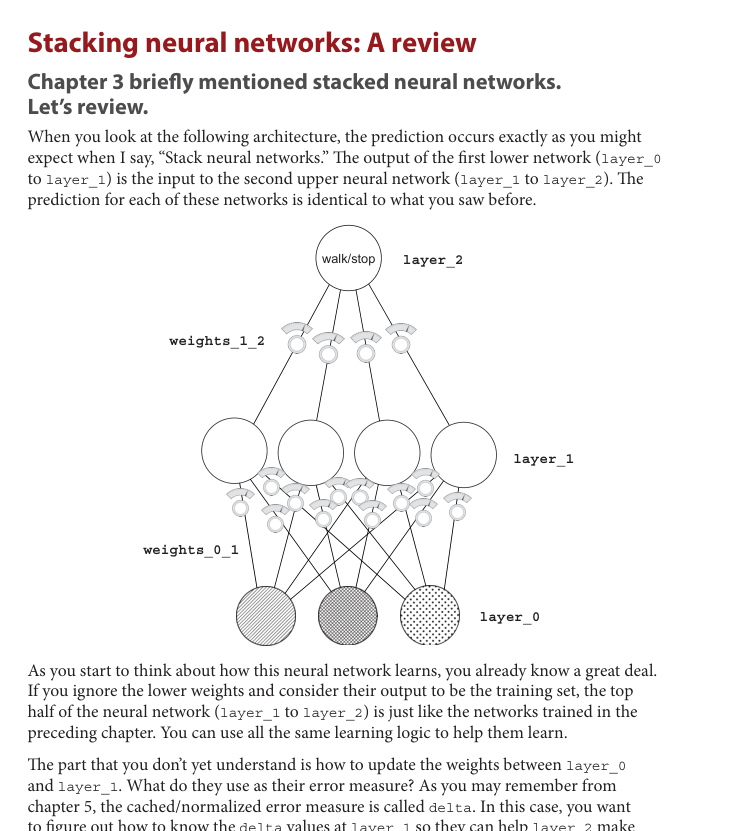

## Backpropagation: Long-distance error attribution

Backpropagation adalah proses memindahkan sinyal delta ke belakang agar error attribution dapat dilakukan pada layer sebelumnya.

Prediction dari `layer_1` ke `layer_2` adalah weighted average dari nilai pada `layer_1`. Jika `layer_2` terlalu tinggi atau terlalu rendah, node pada `layer_1` yang memiliki weight lebih besar berkontribusi lebih besar terhadap error. Node dengan weight lebih kecil berkontribusi lebih kecil.

Untuk mendapatkan delta pada `layer_1`, `layer_2_delta` dikalikan dengan weights yang menghubungkan `layer_1` ke `layer_2`.

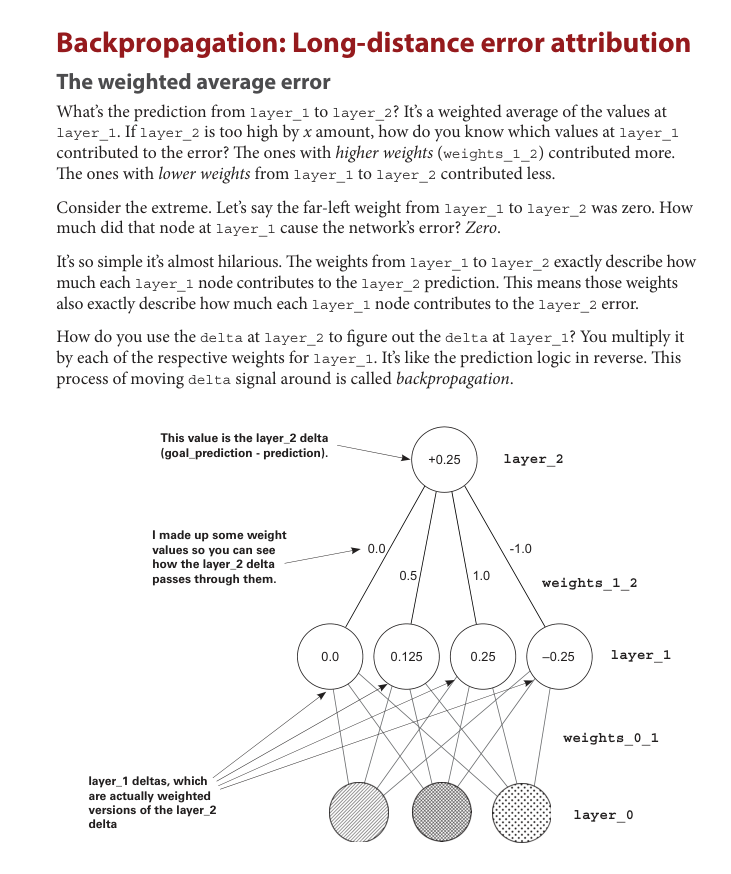

## Backpropagation: Why does this work?

`delta` menunjukkan arah dan jumlah sebuah node perlu berubah. Backpropagation memungkinkan statement seperti: jika node output harus naik sejumlah x, maka node sebelumnya harus naik atau turun sebesar x dikalikan weight penghubungnya.

Saat digunakan secara terbalik, matrix `weights_1_2` memperkuat error dengan jumlah yang sesuai, sehingga diketahui seberapa jauh setiap node `layer_1` harus naik atau turun.

Setelah delta pada layer sebelumnya diketahui, update weight dilakukan seperti sebelumnya: untuk setiap weight, kalikan output delta dengan input value, lalu ubah weight berdasarkan hasilnya.

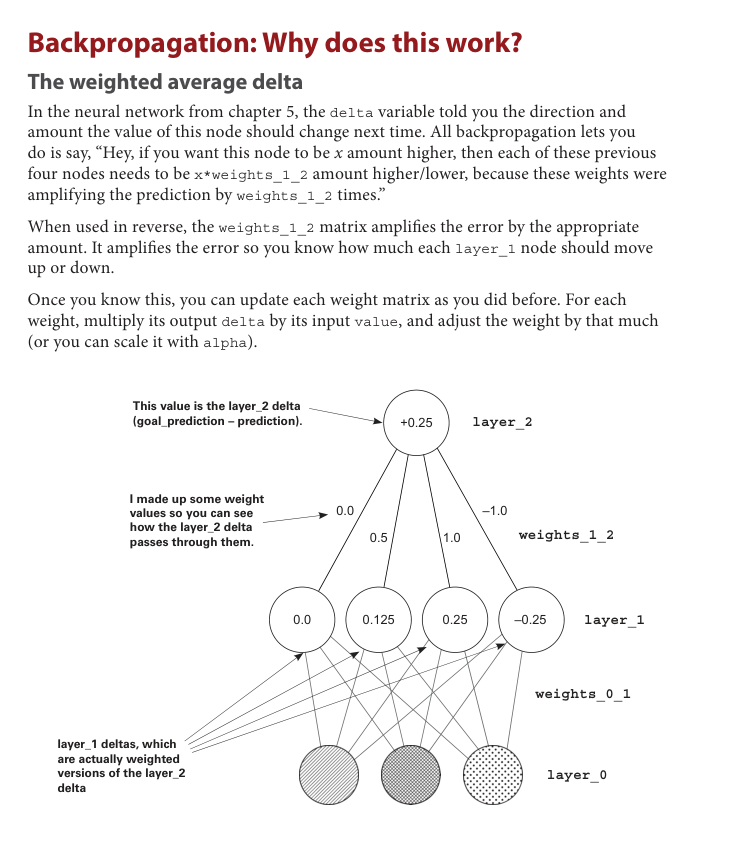

## Linear vs. nonlinear

Bagian ini membahas mengapa network bertumpuk masih membutuhkan satu komponen tambahan.

Dua multiplication berurutan dapat digantikan oleh satu multiplication yang setara. Artinya, dua weighted sums berurutan masih dapat berperilaku seperti satu weighted sum. Jika begitu, stacked neural network belum memberi kekuatan tambahan.

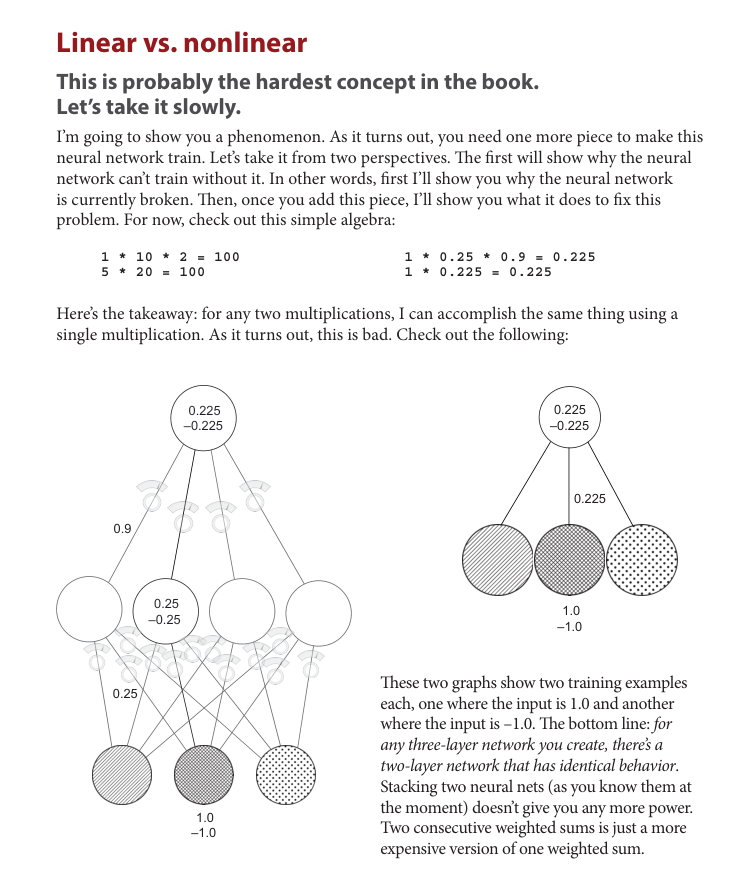

## Why the neural network still doesn’t work

Masalahnya adalah setiap middle node hanya mencampur correlation dari input nodes. Middle nodes belum dapat memiliki correlation sendiri.

Karena dataset baru tidak memiliki correlation langsung antara input dan output, middle layer perlu kemampuan untuk **kadang** berkorelasi dengan input dan **kadang tidak**. Hal ini disebut conditional correlation atau sometimes correlation.

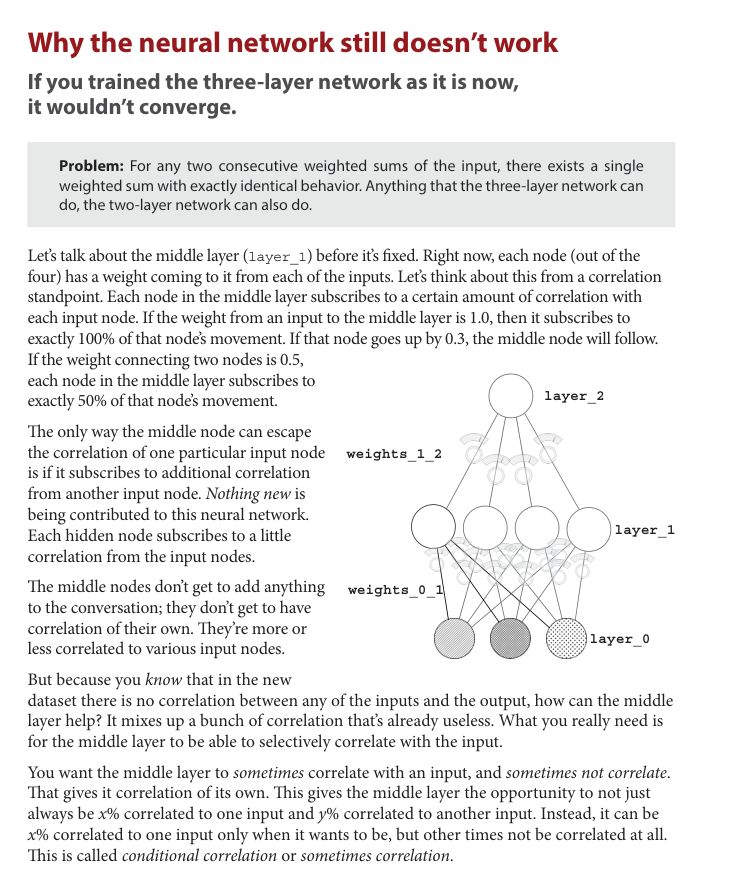

## The secret to sometimes correlation

Rahasia sometimes correlation adalah mematikan node ketika nilainya di bawah 0.

Jika node bernilai negatif lalu diset menjadi 0, node tersebut tidak memiliki correlation dengan input pada saat itu. Dengan cara ini, node dapat memilih kapan berkorelasi dengan input dan kapan tidak.

Logika “jika node negatif, ubah menjadi 0” disebut nonlinearity. Nonlinearity yang digunakan di sini disebut **relu**. Tanpa nonlinearity, neural network bersifat linear dan stacked matrix multiplications tidak menambah kemampuan yang berarti.

## A quick break

Bagian ini menegaskan bahwa neural network mencari correlation antara input dan output. Jika tidak ada correlation langsung, network perlu membangun intermediate layer yang dapat membentuk correlation baru.

Pada titik ini, pembahasan bergerak dari detail granular gradient descent menuju pemahaman tingkat lebih tinggi tentang correlation dan intermediate representation.

## Your first deep neural network

Kode berikut menginisialisasi weights dan melakukan forward propagation pada deep neural network pertama.

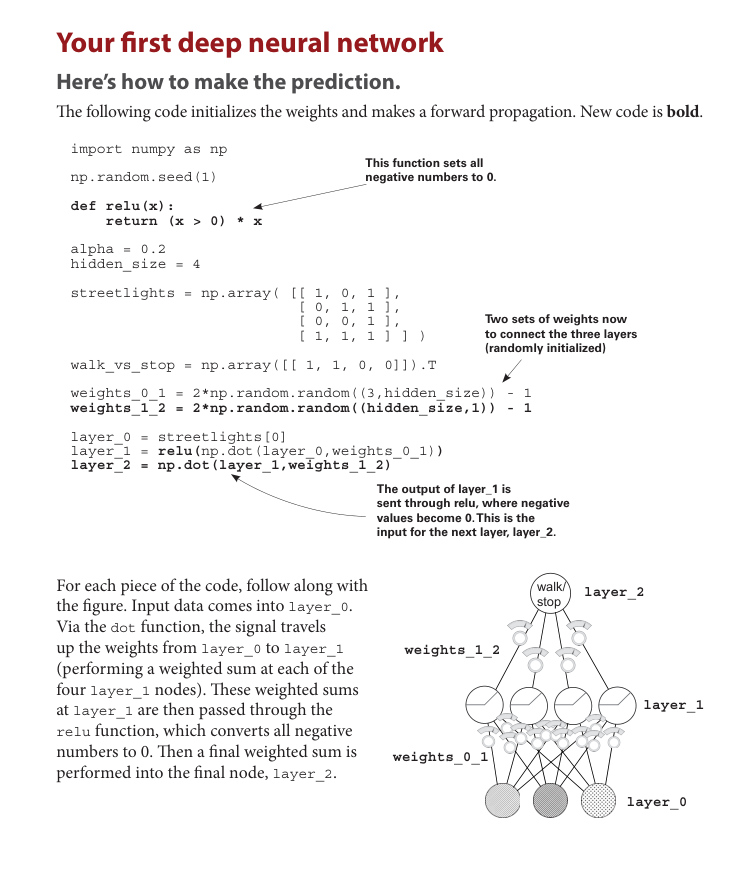

In [5]:
import numpy as np

np.random.seed(1)

def relu(x):
  return (x > 0) * x

alpha = 0.2
hidden_size = 4

streetlights = np.array([
  [1, 0, 1],
  [0, 1, 1],
  [0, 0, 1],
  [1, 1, 1]
])

walk_vs_stop = np.array([[1, 1, 0, 0]]).T

weights_0_1 = 2 * np.random.random((3, hidden_size)) - 1
weights_1_2 = 2 * np.random.random((hidden_size, 1)) - 1

layer_0 = streetlights[0]
layer_1 = relu(np.dot(layer_0, weights_0_1))
layer_2 = np.dot(layer_1, weights_1_2)

print("layer_1:", layer_1)
print("layer_2:", layer_2)

layer_1: [-0.          0.51828245 -0.         -0.        ]
layer_2: [0.39194327]


Input masuk ke `layer_0`. Sinyal bergerak dari `layer_0` ke `layer_1` melalui `weights_0_1` dengan dot product. Hasil di `layer_1` melewati `relu`, sehingga nilai negatif menjadi 0. Setelah itu, weighted sum terakhir dilakukan menuju `layer_2`.

## Backpropagation in code

Kode berikut melatih deep neural network dengan backpropagation.

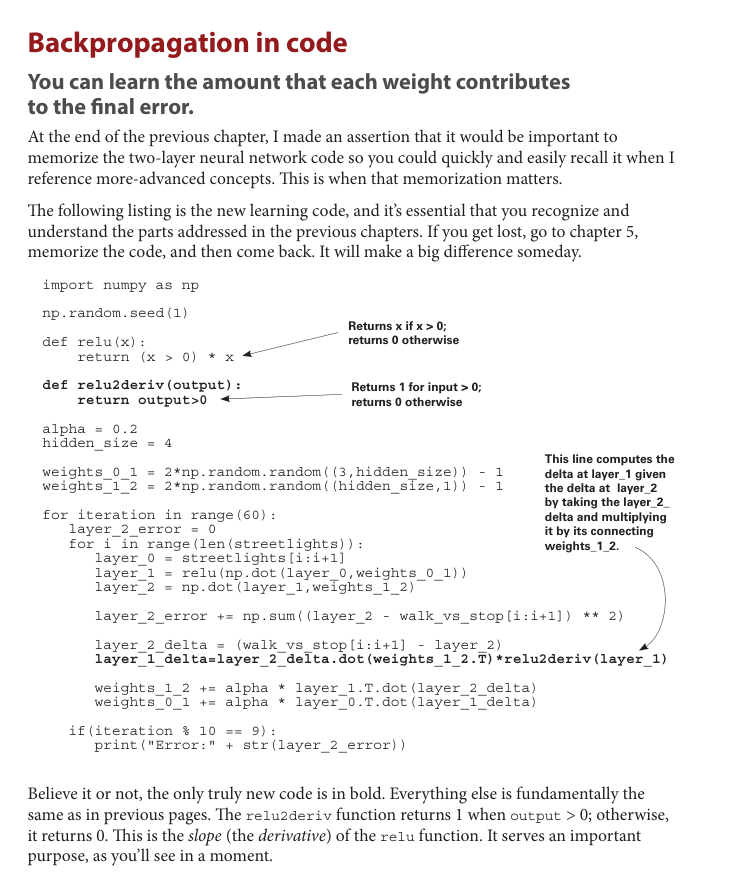

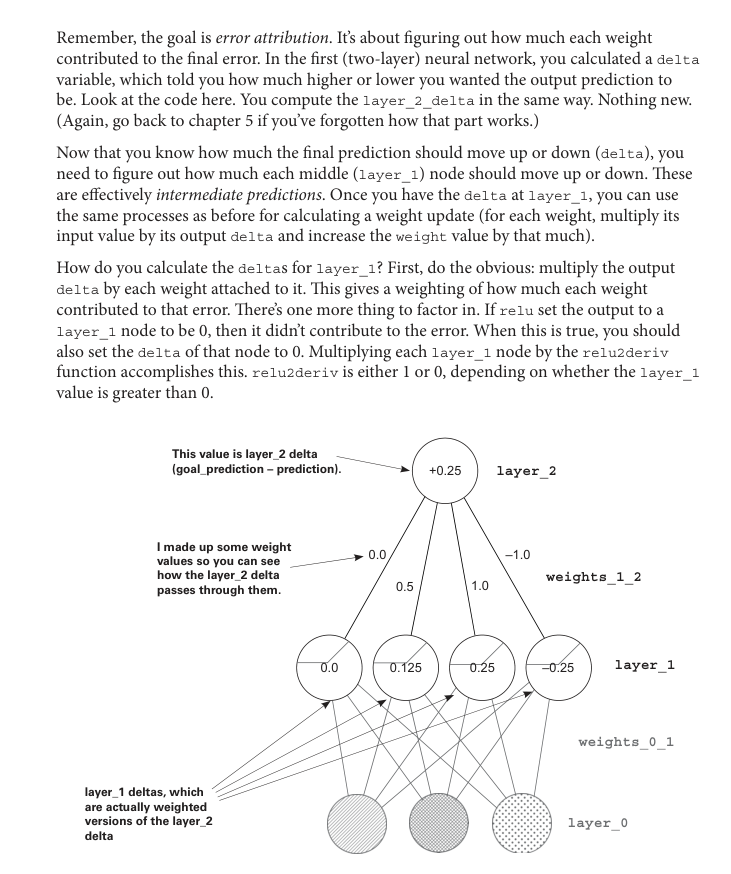

In [6]:
import numpy as np

np.random.seed(1)

def relu(x):
  return (x > 0) * x

def relu2deriv(output):
  return output > 0

streetlights = np.array([
  [1, 0, 1],
  [0, 1, 1],
  [0, 0, 1],
  [1, 1, 1]
])

walk_vs_stop = np.array([[1, 1, 0, 0]]).T

alpha = 0.2
hidden_size = 4

weights_0_1 = 2 * np.random.random((3, hidden_size)) - 1
weights_1_2 = 2 * np.random.random((hidden_size, 1)) - 1

for iteration in range(60):
  layer_2_error = 0

  for i in range(len(streetlights)):
    layer_0 = streetlights[i:i + 1]
    layer_1 = relu(np.dot(layer_0, weights_0_1))
    layer_2 = np.dot(layer_1, weights_1_2)

    layer_2_error += np.sum((layer_2 - walk_vs_stop[i:i + 1]) ** 2)

    layer_2_delta = layer_2 - walk_vs_stop[i:i + 1]
    layer_1_delta = layer_2_delta.dot(weights_1_2.T) * relu2deriv(layer_1)

    weights_1_2 -= alpha * layer_1.T.dot(layer_2_delta)
    weights_0_1 -= alpha * layer_0.T.dot(layer_1_delta)

  if iteration % 10 == 9:
    print("Error:" + str(layer_2_error))

Error:0.6342311598444467
Error:0.35838407676317513
Error:0.0830183113303298
Error:0.006467054957103705
Error:0.0003292669000750734
Error:1.5055622665134859e-05


`relu2deriv` mengembalikan 1 ketika output lebih besar dari 0, dan 0 ketika tidak. Ini adalah slope atau derivative dari `relu`.

Tujuan backpropagation adalah error attribution: mencari tahu berapa kontribusi setiap weight terhadap final error. `layer_2_delta` dihitung seperti delta pada network sebelumnya. Setelah itu, delta pada `layer_1` dihitung dari `layer_2_delta` dan `weights_1_2`.

Jika `relu` membuat output node di `layer_1` menjadi 0, node tersebut tidak berkontribusi terhadap error. Karena itu, delta node tersebut juga dibuat 0 melalui `relu2deriv`.

## One iteration of backpropagation

Bagian ini menunjukkan satu iterasi backpropagation secara terpisah.

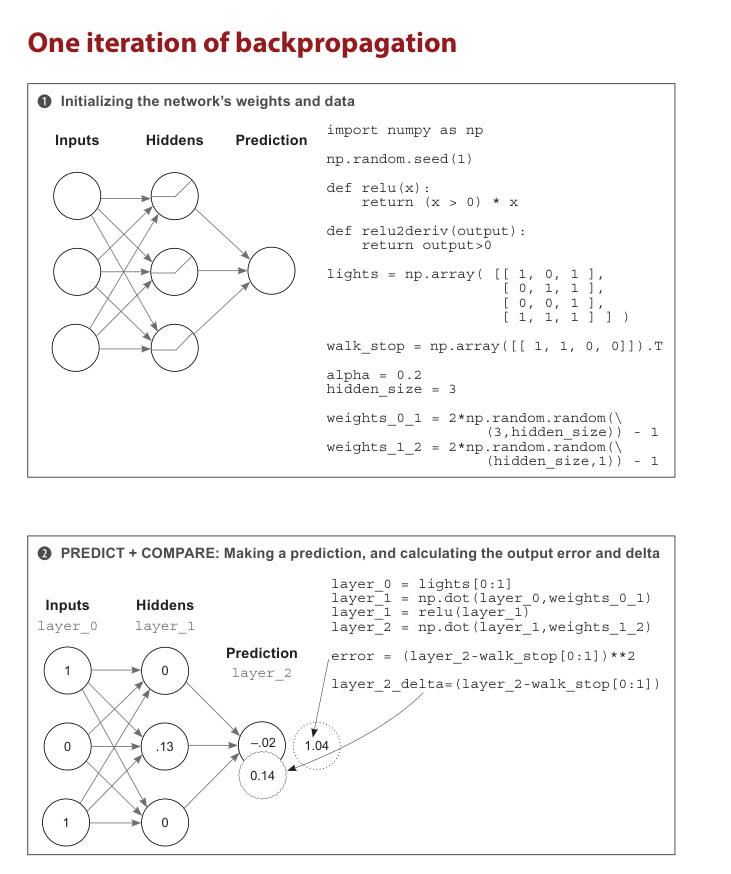

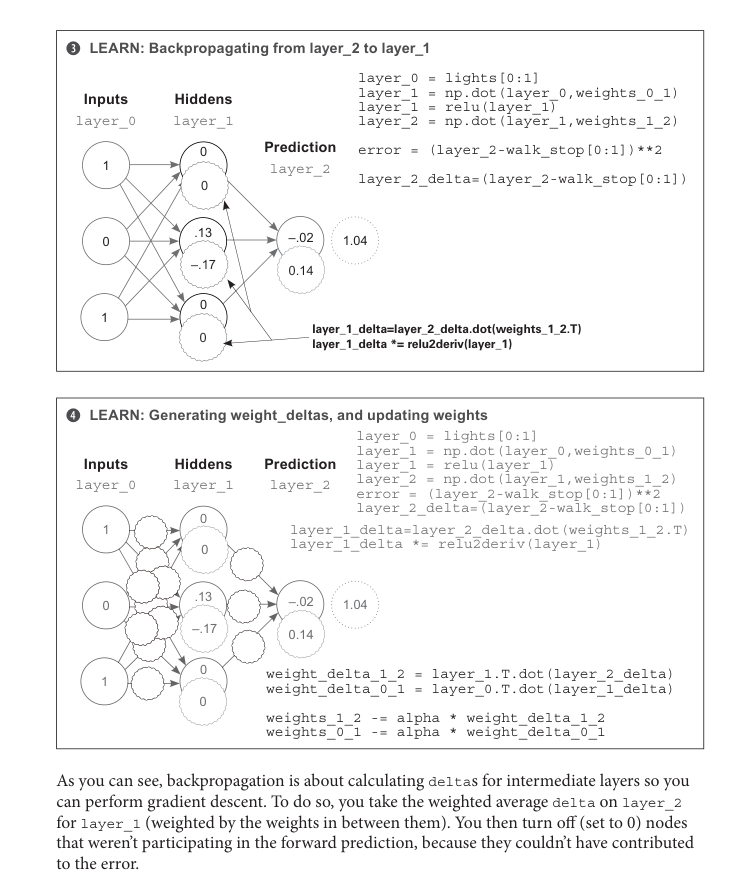

In [7]:
import numpy as np

np.random.seed(1)

def relu(x):
  return (x > 0) * x

def relu2deriv(output):
  return output > 0

lights = np.array([
  [1, 0, 1],
  [0, 1, 1],
  [0, 0, 1],
  [1, 1, 1]
])

walk_stop = np.array([[1, 1, 0, 0]]).T

alpha = 0.2
hidden_size = 3

weights_0_1 = 2 * np.random.random((3, hidden_size)) - 1
weights_1_2 = 2 * np.random.random((hidden_size, 1)) - 1

layer_0 = lights[0:1]
layer_1 = np.dot(layer_0, weights_0_1)
layer_1 = relu(layer_1)
layer_2 = np.dot(layer_1, weights_1_2)

error = (layer_2 - walk_stop[0:1]) ** 2
layer_2_delta = layer_2 - walk_stop[0:1]

layer_1_delta = layer_2_delta.dot(weights_1_2.T)
layer_1_delta *= relu2deriv(layer_1)

weight_delta_1_2 = layer_1.T.dot(layer_2_delta)
weight_delta_0_1 = layer_0.T.dot(layer_1_delta)

weights_1_2 -= alpha * weight_delta_1_2
weights_0_1 -= alpha * weight_delta_0_1

print("layer_0:", layer_0)
print("layer_1:", layer_1)
print("layer_2:", layer_2)
print("error:", error)
print("layer_2_delta:", layer_2_delta)
print("layer_1_delta:", layer_1_delta)
print("weight_delta_1_2:", weight_delta_1_2)
print("weight_delta_0_1:", weight_delta_0_1)

layer_0: [[1 0 1]]
layer_1: [[-0.          0.13177044 -0.        ]]
layer_2: [[-0.02129555]]
error: [[1.0430446]]
layer_2_delta: [[-1.02129555]]
layer_1_delta: [[-0.          0.16505257 -0.        ]]
weight_delta_1_2: [[ 0.        ]
 [-0.13457656]
 [ 0.        ]]
weight_delta_0_1: [[0.         0.16505257 0.        ]
 [0.         0.         0.        ]
 [0.         0.16505257 0.        ]]


Backpropagation menghitung delta untuk intermediate layers agar gradient descent dapat dilakukan. Caranya adalah mengambil weighted delta dari `layer_2` untuk `layer_1`, lalu mematikan node yang tidak ikut berpartisipasi dalam forward prediction.

## Putting it all together

Kode berikut adalah program self-sufficient yang dapat dijalankan.

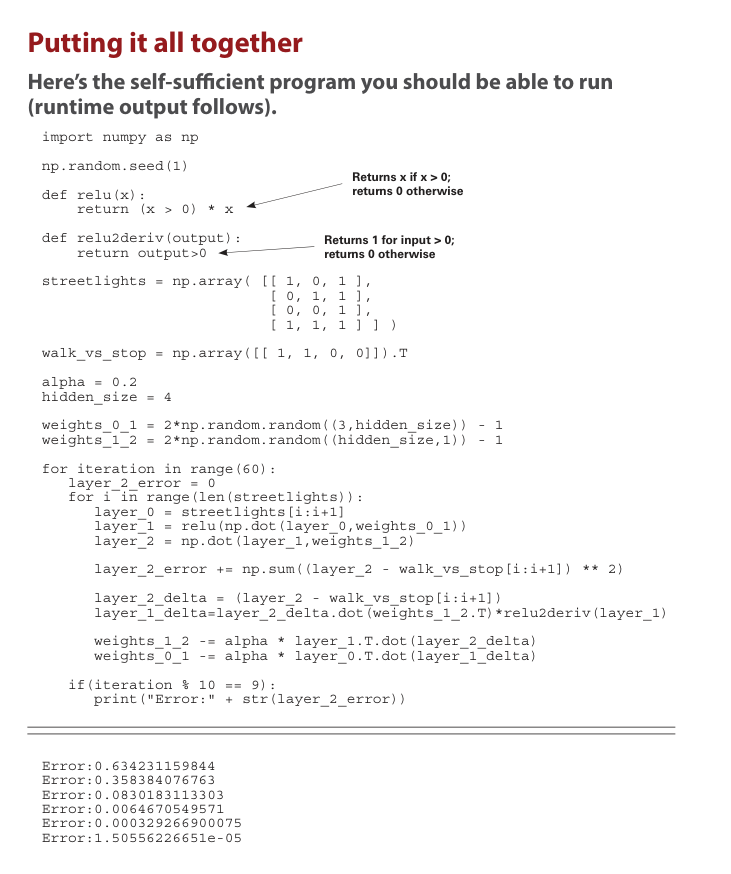

In [8]:
import numpy as np

np.random.seed(1)

def relu(x):
  return (x > 0) * x

def relu2deriv(output):
  return output > 0

streetlights = np.array([
  [1, 0, 1],
  [0, 1, 1],
  [0, 0, 1],
  [1, 1, 1]
])

walk_vs_stop = np.array([[1, 1, 0, 0]]).T

alpha = 0.2
hidden_size = 4

weights_0_1 = 2 * np.random.random((3, hidden_size)) - 1
weights_1_2 = 2 * np.random.random((hidden_size, 1)) - 1

for iteration in range(60):
  layer_2_error = 0

  for i in range(len(streetlights)):
    layer_0 = streetlights[i:i + 1]
    layer_1 = relu(np.dot(layer_0, weights_0_1))
    layer_2 = np.dot(layer_1, weights_1_2)

    layer_2_error += np.sum((layer_2 - walk_vs_stop[i:i + 1]) ** 2)

    layer_2_delta = layer_2 - walk_vs_stop[i:i + 1]
    layer_1_delta = layer_2_delta.dot(weights_1_2.T) * relu2deriv(layer_1)

    weights_1_2 -= alpha * layer_1.T.dot(layer_2_delta)
    weights_0_1 -= alpha * layer_0.T.dot(layer_1_delta)

  if iteration % 10 == 9:
    print("Error:" + str(layer_2_error))

Error:0.6342311598444467
Error:0.35838407676317513
Error:0.0830183113303298
Error:0.006467054957103705
Error:0.0003292669000750734
Error:1.5055622665134859e-05


Latihan pada akhir chapter meminta kode tiga-layer neural network dipahami dan dibuat ulang. Kode pada bagian ini sudah menjadi versi lengkap yang dapat dijalankan.

## Why do deep networks matter?

Deep networks penting karena dapat membuat intermediate layers yang memiliki correlation.

Pada gambar kucing, tidak ada satu pixel individu yang selalu berkorelasi langsung dengan keberadaan kucing. Yang berkorelasi adalah konfigurasi pixel tertentu. Deep learning bekerja dengan membuat intermediate layers yang node-nya merepresentasikan ada atau tidaknya konfigurasi input tertentu.

Untuk dataset gambar kucing, middle layer dapat mencoba mengidentifikasi konfigurasi pixel seperti telinga, mata kucing, atau bulu kucing. Kehadiran banyak konfigurasi yang mirip kucing memberi final layer informasi yang diperlukan untuk memprediksi apakah ada kucing dalam gambar.

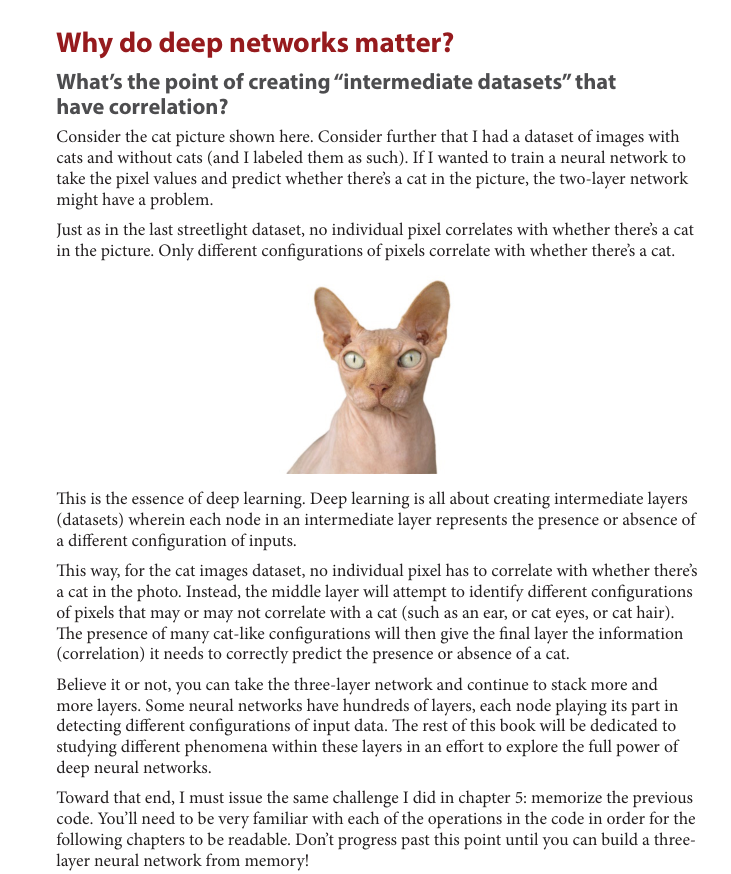

Deep neural networks dapat terus ditumpuk menjadi lebih banyak layer. Setiap node berperan mendeteksi konfigurasi berbeda dari input data.

## Summary

Chapter ini membangun deep neural network pertama dan memperkenalkan backpropagation.

Streetlight problem digunakan untuk memahami bagaimana network belajar dari dataset. Matrix digunakan untuk merepresentasikan input dan output. Stochastic gradient descent melatih network satu example pada satu waktu. Neural network belajar dengan mencari correlation antara input dan output.

Ketika correlation langsung tidak ada, network dapat membuat intermediate layer. Backpropagation digunakan untuk mengirim delta ke layer sebelumnya agar weights pada layer awal juga dapat diperbarui. Nonlinearity seperti `relu` membuat middle layer dapat memiliki conditional correlation, sehingga network bertumpuk menjadi lebih berguna daripada sekadar weighted sum berurutan.